# Companies House - EDA and Dataset Cleansing

This script concentrates on exploring the Companies House data which was loaded, formatted and saved in an *CH_Get_Data.pynb*.

Some helper functions have been defined in *utils.py* and *visualisations.py* to ensure that this script is shorter. A lot of the notes regarding steps taken have been left inside the code cells within this script to keep it shorter vs placing extra notes within markdown cells.

The goal of this script is to explore the potential feature columns, deal with duplication if there is any, decide upon which columns are suitable for the logistic regression modelling and conduct feature engineering on columns that require a little assistance to be meaningful to the model.

The logistic regression model is built in *CH_Log_Reg_Model.pynb*.

## Libraries and Data Loading

In [1]:
# ---------------------------------------------------------
# Library imports
# ---------------------------------------------------------

# Standard library
import os                                         # File and directory operations
import sys                                        # Gives access to Python's system-level variables and functions
sys.path.append(os.path.abspath(".."))            # Needed so the notebook can find src/

# Core analysis libraries
import pandas as pd          # DataFrames and data manipulation
import numpy as np           # Numerical operations and array utilities

# Visualisation
import seaborn as sns             # Statistical plots and quick EDA visuals
import matplotlib.pyplot as plt   # Custom plots and figure control

# File handling
from pathlib import Path     # OS-agnostic filesystem path handling

# Statistical tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Used to calculate VIF for multicollinearity checks
#import scipy.stats as ss      # Statistical tests (normality, correlations, etc.)
from numpy.linalg import inv  # Matrix inversion (used in some diagnostics)

# Utilities
from datetime import date     # For date stamping outputs

# Import src helper functions
from src import (
    find_project_root,               # Dataset summary helper (utils.py)
    mask_user,                       # Masking the username helper (utils.py)
    print_dataset_shape,             # reporting dataset shape helper (utils.py)
    drop_columns_and_report,         # dropping columns with a shape check helper (utils.py)
    value_counts_table,              # producing value‑count tables with percentages helper (utils.py)
    map_categories,                  # mapping messy category labels to cleaner groups helper (utils.py)  
    plot_numeric_distribution,       # bar-chart distribution of numeric values helper (visualisations.py)
    plot_histogram,                  # simple histogram for numeric variables helper (visualisations.py)
    plot_categorical_association     # heatmap of Cramer's V across categorical columns) helper (visualisations.py)
)

In [2]:
# Use the 'find_project_root' helper function from 'utils.py' to define the base directory for the project
# this is used to create all other file paths
BASE_DIR = find_project_root(Path.cwd())

# Define the directory structure for raw and processed data
data_dir = BASE_DIR / "Companies_House"
processed_dir = data_dir / "data_processed"
final_path = processed_dir / "company_psc_dataset.parquet"
model_ready_data_path = processed_dir / "model_ready_data.parquet"

In [3]:
# Load the dataset using the objects above which also combine with the 'find_project_root' helper function from 'utils.py'
df = pd.read_parquet(final_path)

# Print the shape of the dataset
print_dataset_shape(df)

# Display the top 5 rows
df.head()

rows: 5,677,276
columns: 13


,company_number,company_category,company_age_when_acc_due,accounts_category,industry,country_of_origin,registered_country,psc_count,has_corporate_psc,has_foreign_psc,has_sanctioned_psc,recent_psc_change,overdue
0,1,Private Limited Company,9.204654,MICRO ENTITY,77299 - Renting and leasing of other personal ...,United Kingdom,ENGLAND,1,0,1,0,0,0
1,2,Community Interest Company,6.748802,TOTAL EXEMPTION FULL,62090 - Other information technology service a...,United Kingdom,ENGLAND,1,0,1,0,0,0
2,3,Private Limited Company,7.753593,UNAUDITED ABRIDGED,62012 - Business and domestic software develop...,United Kingdom,ENGLAND,3,0,1,0,0,0
3,4,Private Limited Company,8.774812,MICRO ENTITY,56102 - Unlicensed restaurants and cafes,United Kingdom,UNITED KINGDOM,2,0,1,0,0,1
4,5,Charitable Incorporated Organisation,NaN,NO ACCOUNTS FILED,None Supplied,United Kingdom,None,0,0,0,0,0,0


### Distribution of Target Variable
Check the distribution of the *overdue* flag, which is target variable that describes whether or not a company has filed *on-time* or will be considered *late* should they file from now on.

In [4]:
# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "overdue", hide_index=True)

overdue,count,percentage
0,"5,235,729",92.22%
1,"441,547",7.78%


This shows that **92.22%** of companies did not file late, and **7.78%** of companies have not filed on time.
Although **<8%** of companies filing late is small, it is still worth conducting this exercise as that still amounts to **~440k** companies. The *baseline* late filing rate for the dataset is **~7.78%**.

### Column Types, Unique and Missing Values

Here I investigate the columns, looking at the names of each, the data types, how many unique values are held in each column, how many have missing values, and what percentage of the dataset is missing overall.

**Note:** missing counts *np.nan*, *None*, *pd.NA*, *NaT* (missing datetime) as missing, but does not check for "", " ", "NA" or "N/A" values.

In [5]:
summary = pd.DataFrame({
    "column": df.columns,                            # Explicit column names
    "dtype": df.dtypes,                              # Data types
    "unique": df.nunique(),                          # Unique counts
    "missing": df.isna().sum(),                      # Missing counts
    "missing_%": (df.isna().sum() / len(df)) * 100   # Percentage of missing values
})

# Display the results, hide the index for a clear dataframe
summary.sort_values("missing_%", ascending=False).style.hide(axis="index")

column,dtype,unique,missing,missing_%
registered_country,object,205,950019,16.733712
company_age_when_acc_due,float64,37291,170582,3.004645
company_number,int64,5677276,0,0.000000
accounts_category,object,16,0,0.000000
company_category,object,28,0,0.000000
industry,object,1165,0,0.000000
country_of_origin,object,229,0,0.000000
psc_count,int64,62,0,0.000000
has_corporate_psc,int64,2,0,0.000000
has_foreign_psc,int64,2,0,0.000000


There are **13** columns in total:
- **1** unique identifier **"company_number"**. This will be dropped prior to logistic regression modelling as it won't be needed, but is retained through this script in case it is needed for reference.
- **1** target variable *(overdue)*.
- **11** potential feature variables,
    - **5** *object* type (we assume here non-numeric)
    - **6** feature variables, either *float64* or *int64* (numeric types).

- **"registered_country"** shows **~950k** missing values, which is **~16.7%** of the population, this is too large of a percentage to remove, therefore the country will be imputed with **"UNKNOWN"**.
- **"company_age_when_acc_due"** shows **~171k** mising values. This is only a small proportion (**~3%**) of the overall population therefore, rather than complete these missing values with a manufactured value (for example **0**, or the mean/median value) they will be removed, to avoid adding bias.
- No other variables display missing values, however there may still be missing values in the form of "", " ", "NA", "N/A", these will be checked for at points where necessary in this script prior to logistic regression modelling in *CH_Log_Reg_Model.pynb*.
- **5** columns (*has_corporate_psc, has_foreign_psc, has_sanctioned_psc, recent_psc_change, overdue*) each contain only **2** unique values. Given the name of the columns this infers binary data within.

In [6]:
# Impute missing registered_country as "UNKNOWN"
df["registered_country"] = df["registered_country"].fillna("UNKNOWN")

# Drop rows where age is missing as this is only a small proportion of the overall population ~3%
df = df.dropna(subset=["company_age_when_acc_due"])
# Display the shape of the dataframe
print_dataset_shape(df)

rows: 5,506,694
columns: 13


The dataset now contains **13** columns, and should show one entry per company, so here duplication is tested for.

In [7]:
print(f"Duplicate company numbers: {df['company_number'].duplicated().sum():,}")

Duplicate company numbers: 0


There are no duplicated entries for companies therefore this analysis can continue.

## Categorical Column EDA

Here I explore the *object* variables *(accounts_category, company_category, country_of_origin, registered_country and industry)*.
<br><br>
This exploration is focussed on determining the cleanliness of each column, and whether any categories require combining to make fewer categories per variable. 

### 1. Accounts Category

Display the values entered in the *accounts_category* column along with counts in descending order.

In [8]:
df["accounts_category"].value_counts().to_frame("count").reset_index(names="accounts_category")

,accounts_category,count
0,MICRO ENTITY,1829713
1,TOTAL EXEMPTION FULL,1330380
2,NO ACCOUNTS FILED,1282488
3,DORMANT,668992
4,UNAUDITED ABRIDGED,164997
5,FULL,81046
6,SMALL,68879
7,AUDIT EXEMPTION SUBSIDIARY,32724
8,GROUP,27300
9,TOTAL EXEMPTION SMALL,9075


There are no missing or unusual looking values in this field.

The *accounts_category* describes the type of annual accounts a company files, based on its size and exemptions. They do not describe different legal obligations, they describe what they file, not when they file it.
There are **16** different entry types here, some of which are exempt from filing accounts see [Guidance:
Preparing and filing Companies House accounts. (Updated 20 April 2026)](https://www.gov.uk/government/publications/life-of-a-company-annual-requirements/life-of-a-company-part-1-accounts)

As some companies are not required to file accounts they will now be removed from the dataset, so that they do not affect the target variable, therefore I conduct some preliminary decluttering of the data. Companies using the following labels in *accounts_category* will be removed for the reasons given next to each label. Including these in the data will artificially inflate the late filing rate, their lateness is not comparable to those that are legally obliged to file and therefore their characteristics should not be used to determine patterns within the data around late filing indicators.
<br><br>
- **TOTAL EXEMPTION (SMALL/FULL):** Used by companies that are legally exempt from filing full accounts.
- **FILING EXEMPTION SUBSIDIARY:** Allows the subsidiary to file via their parent company's group accounts. They cannot be late as they have no filing obligation.
- **AUDIT EXEMPTION SUBSIDIARY:** Relates to audit requirements rather than filing obligations, however subsidiary companies often use this exemption code when they consolidated their accounts via their parent company, therefore their own accounts may not exist in the dataset.
- **ACCOUNTS TYPE NOT AVAILABLE:** This could be a data quality/availability issue rather than a filing behaviour. It could include newly incorporated companies who are too new to have filed yet and dissolved companies who no longer have to file.
- **INITIAL:** This could be a data quality/availability issue rather than a filing behaviour as the companies have not yet reached their first filing deadline, therefore they cannot be considered late or on-time yet.
- **NO ACCOUNTS FILED:** These are newly incorporated companies who's accounts are not yet due thefefore they cannot be considered either late or on-time yet.

In [9]:
# Create a filtered VIEW dataset for analysis only, being careful to not filter the original dataset
# This allows me to observe the effects of removing the 'accounts_categories' listed above before making decisions on next steps.

# Remove those where the accounts_category is in the unwanted list
accounts_category_filtered = df[              
    ~df["accounts_category"].isin([
        "ACCOUNTS TYPE NOT AVAILABLE",
        "INITIAL",
        "NO ACCOUNTS FILED",
        "TOTAL EXEMPTION SMALL",
        "TOTAL EXEMPTION FULL",
        "AUDIT EXEMPTION SUBSIDIARY",
        "FILING EXEMPTION SUBSIDIARY"
    ])
].copy() # Ensure this is a copy to ensure pandas does not treat this as the original dataset

In [10]:
print(f"Total number of companies required to file: {len(accounts_category_filtered)}")

Total number of companies required to file: 2848256


In [11]:
# Check the distribution of the accounts_category column using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(accounts_category_filtered, "accounts_category")

accounts_category,count,percentage
MICRO ENTITY,"1,829,713",64.24%
DORMANT,"668,992",23.49%
UNAUDITED ABRIDGED,"164,997",5.79%
FULL,"81,046",2.85%
SMALL,"68,879",2.42%
GROUP,"27,300",0.96%
MEDIUM,"6,072",0.21%
AUDITED ABRIDGED,"1,230",0.04%
PARTIAL EXEMPTION,27,0.00%


These **9** remaining accounts category types are legally bound to file some form of accounts to differeng levels and therefore could be categorised as *late* or *on-time* depending on their filing behaviour held within the data.
<br><br>
**~93.2% (64.24 + 23.49 + 5.79)** of the data is held in only **3** categories. Grouping the categories into fewer bandings based on their account filing type by collecting together the groups with smaller percentages/counts, will remove noise from sparsely populated columns that would affect the *one-hot encoding* later.

In [12]:
# Group accounts_category into fewer, meaningful buckets
accounts_category_mapping = {
    "FULL": "FULL",                     # Full statutory accounts – highest disclosure
    "MEDIUM": "FULL",                   # Medium companies file fuller accounts than small/micro
    "GROUP": "FULL",                    # Group accounts – consolidated, treated as full

    "SMALL": "REDUCED",                 # Small companies can file reduced accounts
    "UNAUDITED ABRIDGED": "REDUCED",    # Abridged = reduced disclosure
    "AUDITED ABRIDGED": "REDUCED",      # Same reduced format, but audited
    "PARTIAL EXEMPTION": "REDUCED",     # Partial disclosure exemptions

    "MICRO ENTITY": "SIMPLEST",         # Micro-entity regime – simplest statutory format

    "DORMANT": "MINIMAL"                # Dormant companies file minimal accounts
    # Note: Dormant ≠ exempt. They still must file and can be late.
}

# Apply the mapping to collapse categories using the 'map_categories' helper function from 'utils.py'
accounts_category_filtered["accounts_category"] = map_categories(
    accounts_category_filtered["accounts_category"],
    mapping=accounts_category_mapping
)

# Check the distribution of the accounts_category column using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(accounts_category_filtered, "accounts_category")

accounts_category,count,percentage
SIMPLEST,"1,829,713",64.24%
MINIMAL,"668,992",23.49%
REDUCED,"235,133",8.26%
FULL,"114,418",4.02%


The data is now grouped into **4** *accounts_category* types.

In [13]:
# Create 'accounts_group' column which maps the accounts_category to the 'accounts_category_mapping' grouped labels from above
df["accounts_group"] = df["accounts_category"].map(accounts_category_mapping)

df = df[df["accounts_group"].notna()]                       # keep only mapped categories

# Use the 'drop_columns_and_report' helper function from 'utils.py'
df = drop_columns_and_report(df, columns=["accounts_category"])

print(f"Number of companies legally required to file: {len(df)}")
# Display the top 5 rows
df.head()

rows: 2,848,256
columns: 13
Number of companies legally required to file: 2848256


,company_number,company_category,company_age_when_acc_due,industry,country_of_origin,registered_country,psc_count,has_corporate_psc,has_foreign_psc,has_sanctioned_psc,recent_psc_change,overdue,accounts_group
0,1,Private Limited Company,9.204654,77299 - Renting and leasing of other personal ...,United Kingdom,ENGLAND,1,0,1,0,0,0,SIMPLEST
2,3,Private Limited Company,7.753593,62012 - Business and domestic software develop...,United Kingdom,ENGLAND,3,0,1,0,0,0,REDUCED
3,4,Private Limited Company,8.774812,56102 - Unlicensed restaurants and cafes,United Kingdom,UNITED KINGDOM,2,0,1,0,0,1,SIMPLEST
7,8,Private Limited Company,5.826146,80100 - Private security activities,United Kingdom,ENGLAND,1,0,1,0,0,0,SIMPLEST
9,10,Private Limited Company,18.844627,"46390 - Non-specialised wholesale of food, bev...",United Kingdom,UNKNOWN,1,1,1,0,0,0,MINIMAL


There are **2,848,256 companies** in the population that are legally required to file accounts. The data now has a total of **13** columns consisting of **11** feature columns, **1** unique identifier, and **1** target variable. 

In [14]:
# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "overdue", hide_index=True)

overdue,count,percentage
0,"2,590,974",90.97%
1,"257,282",9.03%


The distribution of late filing has changed with the removal of those that were not required to file. The dataset is now more balanced (*late-filers* increased from **7.78%** to **9.03%**) because I removed exempt companies, subsidiaries filing via parents, companies with no accounts and newly incorporated companies not yet due.
- **2,644,755 companies** have been removed from the **5,235,729 companies** that originally were classified as filing *on-time* in the original population, leaving **2,590,974 companies** that file *on-time*. This **decreased** the proportion of the population of *on-time* filers from **92.22%** to **90.97%**.
- **184,265 companies** have been removed from the **441,547 companies** that originally were classified as filing *late* in the original population, leaving **257,282 companies** that file *late*. This **increased** the proportion of the population of *late-filers* from **7.78%** to **9.03%**.
- The population is now **2,848,256 companies** and the *baseline late-filing rate* has now increased to **9.03%**.

### 2. Country Of Origin
Country of origin may have an impact on filing behaviour due to language and administrative barriers among other factors. First I observe the values entered in the column.

In [15]:
# Check the distribution of the country_of_origin using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, column="country_of_origin")

country_of_origin,count,percentage
United Kingdom,"2,848,256",100.00%


This shows that all companies have the same country of origin (UK). There is no variation in the contents therefore the column offers no predictive power and will be removed, which will leave **12** columns consisting of **10** feature variables, **1** unique identifier, and **1** target variable.

In [16]:
# Use the 'drop_columns_and_report' helper function from 'utils.py'
df = drop_columns_and_report(df, columns=["country_of_origin"])
df.head()

rows: 2,848,256
columns: 12


,company_number,company_category,company_age_when_acc_due,industry,registered_country,psc_count,has_corporate_psc,has_foreign_psc,has_sanctioned_psc,recent_psc_change,overdue,accounts_group
0,1,Private Limited Company,9.204654,77299 - Renting and leasing of other personal ...,ENGLAND,1,0,1,0,0,0,SIMPLEST
2,3,Private Limited Company,7.753593,62012 - Business and domestic software develop...,ENGLAND,3,0,1,0,0,0,REDUCED
3,4,Private Limited Company,8.774812,56102 - Unlicensed restaurants and cafes,UNITED KINGDOM,2,0,1,0,0,1,SIMPLEST
7,8,Private Limited Company,5.826146,80100 - Private security activities,ENGLAND,1,0,1,0,0,0,SIMPLEST
9,10,Private Limited Company,18.844627,"46390 - Non-specialised wholesale of food, bev...",UNKNOWN,1,1,1,0,0,0,MINIMAL


### 3. Registered Country
The registered country is interesting to investigate as companies have different legal juridictions based on their registered country with different filing cultures, administrative processes and enforcement behaviours that may be a risk factor for filing late.

In [17]:
# Check the distribution of the registered_country using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "registered_country")

registered_country,count,percentage
ENGLAND,"1,495,240",52.50%
UNITED KINGDOM,"685,573",24.07%
UNKNOWN,"503,477",17.68%
SCOTLAND,"88,620",3.11%
WALES,"42,568",1.49%
NORTHERN IRELAND,"32,776",1.15%
CYMRU,1,0.00%
UK,1,0.00%


There are no missing values in this field right now as earlier on they were all imputed with ***UNKNOWN***. All values are either **UK** based or **UNKNOWN**. 

Two of these categories **UK** and **CYMRU** contain very low counts, which during *one-hot encoding* would leave the columns almost entirely consisting of zeroes. *One-hot encoding* allows the logistic regression model to handle categorical data.

Using the current setup would add too much noise to the model, therefore my decision is to reduce the number of categories, replacing values so that the data fits into one of the other *registered_country* values, then test the data further by observing the percentage of the population held within each remaining category.

- **UNITED KINDGOM** = **UK** as this uses less characters,
- **CYMRU** = **WALES**, replacing the Welsh language word for Wales.

In [18]:
registered_country_map = {          # Replace each appearance of key entries with a new entry
        "UNITED KINGDOM": "UK",     # Replace shorthand UK with the same standard label
        "CYMRU": "WALES"            # Convert Welsh-language label to its English equivalent
}

# Replace the registered country with the new categories using the 'map_categories' helper function from 'utils.py'
df["registered_country"] = map_categories(df["registered_country"], mapping=registered_country_map)

# Compute counts and percentages for registered_country using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "registered_country")

registered_country,count,percentage
ENGLAND,"1,495,240",52.50%
UK,"685,574",24.07%
UNKNOWN,"503,477",17.68%
SCOTLAND,"88,620",3.11%
WALES,"42,569",1.49%
NORTHERN IRELAND,"32,776",1.15%


This table shows that approximately **~94.25%** of companies are either registered in *ENGLAND* or the *UK* or have an *UNKNOWN* registered country (**52.50% *ENGLAND* + 24.07% *UK* + 17.68 *UNKNOWN*)**. Here I note that **4** of the countries are all nations within the *UK* and that *UNKNOWN* may also largely represent missing *ENGLAND* values, where Companies House may have not captured the information at the time of the company registration. However, the labels attached to each company in the dataset may prove to be predictive, therefore they are not adjusted here.
<br><br>

### 4. Company Category
The company category can give an indication of size and accounting requirements that the company must meet, therefore this could be an important factor in determining lateness. I conduct the same exploration as for the other **2** variables above.

In [19]:
# Check the distribution of the company_category using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "company_category")

company_category,count,percentage
Private Limited Company,"2,716,335",95.37%
"PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)","80,838",2.84%
"PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)","20,298",0.71%
Limited Liability Partnership,"18,640",0.65%
Community Interest Company,"7,920",0.28%
Public Limited Company,"4,211",0.15%
"PRIV LTD SECT. 30 (Private limited company, section 30 of the Companies Act)",13,0.00%
Old Public Company,1,0.00%


The population is split across **8** categories, with no missing or unusual looking values. A large proportion of the population (**95.37%**) are held within the *Private Limited Company* category. During *one-hot encoding* of the categorical variables, this would leaves a lot of columns containing almost entirely zeroes, adding too much noise to the model, therefore I will reduce the number of categories by mapping the category names to some grouped name labels.

**Private limited by shares:**
- Private Limited Company = LTD
- PRIV LTD SECT. 30 (Private limited company, section 30 of the Companies Act) = LTD

**Limited by guarantee / CIC:**
- PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital) = LTD BY GUARANTEE/CIC
- PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption) = LTD BY GUARANTEE/CIC
- Community Interest Company = LTD BY GUARANTEE/CIC

**Partnerships with limited liability:** 
- Limited Liability Partnership = LLP

**Public companies:**
- Public Limited Company = PLC
- Old Public Company = PLC

In [20]:
# Collect the categories into meaningful groupings to give fewer categories
company_category_mapping = {
    # Private limited by shares
    "Private Limited Company": "LTD",
    "PRIV LTD SECT. 30 (Private limited company, section 30 of the Companies Act)": "LTD",

    # Limited by guarantee / CIC
    "PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)": "LTD BY GUARANTEE/CIC",
    "PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)": "LTD BY GUARANTEE/CIC",
    "Community Interest Company": "LTD BY GUARANTEE/CIC",

    # LLP
    "Limited Liability Partnership": "LLP",

    # Public companies
    "Public Limited Company": "PLC",
    "Old Public Company": "PLC",
}

# Replace the old company_category with the new definitions using the mapping above via the 'map_categories' helper function from 'utils.py'
df["company_category"] = map_categories(df["company_category"], mapping=company_category_mapping);

In [21]:
# Check the distribution of the company_category using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "company_category")

company_category,count,percentage
LTD,"2,716,348",95.37%
LTD BY GUARANTEE/CIC,"109,056",3.83%
LLP,"18,640",0.65%
PLC,"4,212",0.15%


This table shows that, as before, **~95%** of the companies are **Private Limited Company (LTD)**.
On the surface this value could be seen as showing not enough variation to be useful but will be tested later along with the other variables to decide whether to drop it or not.

### 4. Industry (SIC)
Industry may affect filing behaviour for a variety of reasons such as seaonality and workload cycles (retail sector), business stability and turnover (building trade) among many others.

The Companies House data captures [Nature of Business: Standard Industrial Classification (SIC) codes](https://resources.companieshouse.gov.uk/sic/) in the *industry* variable. This variable features the SIC code followed by the SIC description.

In [22]:
print(f"There are {df['industry'].nunique():,} unique industries in the dataset.")

There are 1,088 unique industries in the dataset.


**1,088** different entries in the *industry* column will create far too many potentially sparsely populated columns when *one-hot encoding* the data for the logistic regression model. A condensed list will derive more meaningful analytics by categorising companies into higher level industries. To do this the first **2** characters of the variable are extracted, this provides a means of assigning an industry like those that can be seen by [clicking this link](https://resources.companieshouse.gov.uk/sic/). (*Note: Shortened descriptions have been used here.*)

In [23]:
# Extract the first two digits from the industry string and place in a column called 'sic_prefix'
df["sic_prefix"] = df["industry"].str[:2]

# Create a 'sic_map' which will map the SIC prefixes to high level industry category wording based on the first 2 digits of the sic code.
sic_map = {
    **{k: "Primary & Utilities" for k in ["01","02","03","05","06","07","08","09","35","36","37","38","39"]},
    **{f"{i:02d}": "Manufacturing" for i in range(10, 34)},
    **{k: "Construction" for k in ["41","42","43"]},
    **{k: "Wholesale & Retail" for k in ["45","46","47"]},
    **{k: "Transport & Storage" for k in ["49","50","51","52","53"]},
    **{k: "Accommodation & Food" for k in ["55","56"]},
    **{k: "Information & Communication" for k in ["58","59","60","61","62","63"]},
    **{k: "Finance & Insurance" for k in ["64","65","66"]},
    "68": "Real Estate",
    **{k: "Professional, Scientific & Tech" for k in ["69","70","71","72","73","74","75"]},
    **{k: "Admin & Support Services" for k in ["77","78","79","80","81","82"]},
    **{k: "Health & Social Care" for k in ["86","87","88"]},
    **{k: "Other Services" for k in ["90","91","92","93","94","95","96","85","97","98"]},
    **{k: "Public & Non-Market" for k in ["84","99"]},
}

# Map the SIC prefixes to the high level category wording, ensuring any that do not map are categorised as UNKNOWN.
df["industry"] = df["sic_prefix"].map(sic_map).fillna("UNKNOWN")

# Remove sic_prefix column as it is no longer needed, using the 'drop_columns_and_report' helper function from 'utils.py'
df = drop_columns_and_report(df, columns=["sic_prefix"])
df.head()

rows: 2,848,256
columns: 12


,company_number,company_category,company_age_when_acc_due,industry,registered_country,psc_count,has_corporate_psc,has_foreign_psc,has_sanctioned_psc,recent_psc_change,overdue,accounts_group
0,1,LTD,9.204654,Admin & Support Services,ENGLAND,1,0,1,0,0,0,SIMPLEST
2,3,LTD,7.753593,Information & Communication,ENGLAND,3,0,1,0,0,0,REDUCED
3,4,LTD,8.774812,Accommodation & Food,UK,2,0,1,0,0,1,SIMPLEST
7,8,LTD,5.826146,Admin & Support Services,ENGLAND,1,0,1,0,0,0,SIMPLEST
9,10,LTD,18.844627,Wholesale & Retail,UNKNOWN,1,1,1,0,0,0,MINIMAL


In [24]:
# Check the distribution of the industry using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "industry")

industry,count,percentage
"Professional, Scientific & Tech","388,105",13.63%
Other Services,"344,574",12.10%
Wholesale & Retail,"341,795",12.00%
Real Estate,"294,058",10.32%
Construction,"284,356",9.98%
Information & Communication,"252,176",8.85%
Admin & Support Services,"211,687",7.43%
Accommodation & Food,"131,950",4.63%
Manufacturing,"124,551",4.37%
Health & Social Care,"121,592",4.27%


The distribution across the **15** *industry* categories shows a good spread of data, there are some missing values but these have been imputed as ***UNKNOWN*** as not having the industry recorded could be a predictor of non-compliance. They are not added into the *Other Services* category as *Other* is not the same as ***UNKNOWN*** however when running this model again we could potentially combine these categories to reduce noise.

The top **5** industries account for approximately **70%** of the population and the numbers suggest that the feature contains sufficient variation to be potentially useful in the model.

## Numeric Column EDA

The statistical descriptors for numeric columns, is used below to identify if:
- any columns can be dropped,
- any values need to be imputed,
- outliers require handling,
- features require engineering.

In [25]:
# Use the describe function to show summary statistics on the numeric variables, rounding to 2.dp.
df.describe(include=[np.number]).style.format("{:,.2f}")

,company_number,company_age_when_acc_due,psc_count,has_corporate_psc,has_foreign_psc,has_sanctioned_psc,recent_psc_change,overdue
count,"2,848,256.00","2,848,256.00","2,848,256.00","2,848,256.00","2,848,256.00","2,848,256.00","2,848,256.00","2,848,256.00"
mean,"2,838,910.25",11.19,1.57,0.11,0.60,0.00,0.04,0.09
std,"1,639,020.22",11.04,1.00,0.31,0.49,0.00,0.19,0.29
min,1.00,1.27,0.00,0.00,0.00,0.00,0.00,0.00
25%,"1,418,809.75",4.73,1.00,0.00,0.00,0.00,0.00,0.00
50%,"2,838,745.00",7.78,1.00,0.00,1.00,0.00,0.00,0.00
75%,"4,258,577.25",13.79,2.00,0.00,1.00,0.00,0.00,0.00
max,"5,677,275.00",170.24,156.00,1.00,1.00,0.00,1.00,1.00


Looking at the information in this table above:
- **company_age_when_acc_due:** has a wide range **1.27yrs to ~170yrs** with a good variance (**~122 years**) and a strong potential relevance, there is an assumption that older companies could be more compliant than younger companies who perhaps are still learning the rules. This feature will be retained and investigated further against lateness.
- **psc_count:** has a wide range **0-156** per company, which may give a meaningful signal, perhaps due to those with higher *psc_count* having more controlling minds for the accounts to pass through and therefore a higher level of complexity within the business than those with no or few PSCs. Given the standard deviation/variance of **1 year** and **max=156 years** this distribution is **heavily right-skewed** and will contain outliers, which will affect the logistic regression model. This variable will be retained and tested with a histogram where I will consider clipping/capping the value.
- **has_corporate_psc:** this binary flag has a mean of **0.11**, therefore **11%** of companies have a corporate PSC. This could be a useful compliance signal which may indicate that those with corporate PSCs could be more scrupulous with their accounts, or more organised. However, this must be investigated against lateness to determine usefulness.
- **has_foreign_psc:** this binary flag shows that **60%** of companies have at least one foreign PSC. This could be a useful predictor as cross-border behaviours may affect compliance. This feature will be retained and investigated further.
- **has_sanctioned_psc:** shows that no company has a sanctioned person of significant control all values are **0.0** except for the count so this column shall be dropped from here as it adds no value to the logistic model, only noise.
- **recent_psc_change:** **4%** of companies have had a recent PSC change, this may seem like an insignificant number however it must che chacked against lateness to assess whether or not it has an impact. This variable could suggest that recent governance changes may make a company more compliant than the general population.

One variable (*has_sanctioned_psc*) is dropped here and the others are retained and investigated further.

In [26]:
# Remove has_sanctioned_psc column as it is no longer needed, using the 'drop_columns_and_report' helper function from 'utils.py'
df = drop_columns_and_report(df, columns=["has_sanctioned_psc"])
df.head()

rows: 2,848,256
columns: 11


,company_number,company_category,company_age_when_acc_due,industry,registered_country,psc_count,has_corporate_psc,has_foreign_psc,recent_psc_change,overdue,accounts_group
0,1,LTD,9.204654,Admin & Support Services,ENGLAND,1,0,1,0,0,SIMPLEST
2,3,LTD,7.753593,Information & Communication,ENGLAND,3,0,1,0,0,REDUCED
3,4,LTD,8.774812,Accommodation & Food,UK,2,0,1,0,1,SIMPLEST
7,8,LTD,5.826146,Admin & Support Services,ENGLAND,1,0,1,0,0,SIMPLEST
9,10,LTD,18.844627,Wholesale & Retail,UNKNOWN,1,1,1,0,0,MINIMAL


The number of companies in the population has remained the same, but there are now **11** columns, **1** unique identifier (*company_number*), **1** target variable (*overdue*) and **9** feature variables.

### PSC Columns.

**3** of the PSC columns are binary columns (*has_corporate_psc, has_foreign_psc, recent_psc_count*), they will be investigated further later, along with the other columns that have been retained, where they will be compared against *lateness*.

The other PSC column is not binary therefore a different approach is used. I will check the distribution of the PSC count across the companies to determine whether or not this data exhibits skew, as logistic regression is reliant on a linear relationship.

Here I use a column chart to display the distribution as the PSC count is discrete not continuous.

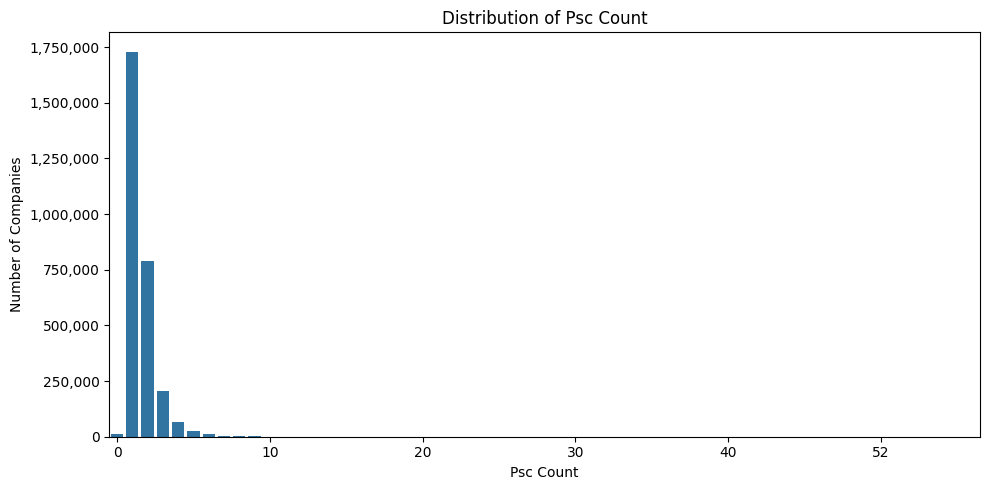

In [27]:
# Use the 'plot_numeric_distribution' function from 'visualisations.py'.
plot_numeric_distribution(df, "psc_count", tick_interval=10);

**Health Warning:** The *x-axis* on the graph is affected by the way *matplotlib* condenses the axes when data becomes sparse, like at the upper end of the PSC count in this case, but it is still usable for the purposes of this analysis.

The PSC count distribution is heavily right-skewed. Most companies have **0-2 PSCs**, with **1 PSC** being by far the most common structure, typical of small private companies with a single controlling director. Companies with **2 PSCs** are the next most common, often reflecting simple multi-director or family-run structures. Counts of **3 or more PSCs** occur progressively less frequently and represent increasingly complex ownership arrangements. Very high PSC counts (e.g. **10+**) exist but are extremely rare and form a long tail to the right of the distribution.

The skewed pattern of the PSC count indicates meaningful variation in ownership complexity across the population, but it also highlights a modelling challenge in that extreme tails violate the linear assumptions of logistic regression modelling and risks allowing a very small number of outlier companies to influence the coefficient in a disproportionate manner. To mitigate this, I will cap the PSC count prior to modelling to reduce the impact of outliers while preserving the underlying signal in the rest of the variable.

The table below shows the final chosen capped value of **15 PSCs**. This was chosen, after a period of iterating different values, to avoid inflating the value of **10+** so that it became much larger than **9 PSCs**, and to preserve some of the variation in values.

In [28]:
# Ensure the variable is numeric before applying transformation to change to "15+".

# Keep the original 'psc_count' where is it less than 15, else change it to "15+"
df["psc_count"] = pd.to_numeric(df["psc_count"], errors="coerce")

df["psc_count"] = (
    df["psc_count"]
    .where(df["psc_count"] < 15, "15+")
    .astype("string")
)

# Check the distribution of the psc_count using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "psc_count", sort=False)

psc_count,count,percentage
1,"1,729,468",60.72%
2,"790,184",27.74%
3,"204,835",7.19%
4,"66,999",2.35%
5,"24,741",0.87%
0,"11,140",0.39%
6,"10,298",0.36%
7,"4,637",0.16%
8,"2,319",0.08%
9,"1,241",0.04%


PSC count still remains a numeric predictor after capping; the engineering only restricted the upper range of the values so that it reduced the influence of outliers. The variable can still be tested for multicolinearity with the rest of the numeric variables.

## Company Age When Account Due

Company age at the point when accounts are due is a continuous numeric variable and has a clear conceptual link to filing behaviour. There is a reasonable assumption that older companies may be more compliant than younger companies, who may still be adapting to statutory reporting obligations, whereas older companies may be more well versed with a good standard of routine in place.

Initial descriptive checks:
- The minimum age is **~1.27 years** which aligns with the expected timing of a company's first accounts becoming due.
- No companies have a **zero or negative age** when their first accounts are due, which confirms that the calculation is behaving correctly and no impossible ages have been generated.
- There are **no missing values**, as confirmed in earlier completeness checks.
- The maximum age is **~170 years**, which is plausible given there may be old banks/railway companies etc. in the data.
- There variance is high (**~122 years**), suggesting the presence of outliers and a wide spread of company ages.

As the variable is continuous and derived from the number of days between incorporation and the account-due date, a **histogram** is the appropriate tool for examining its distribution. This will help identify skewness, outliers and whether any transformation may be required before modelling, for example capping the age like earlier with the number of PSCs.

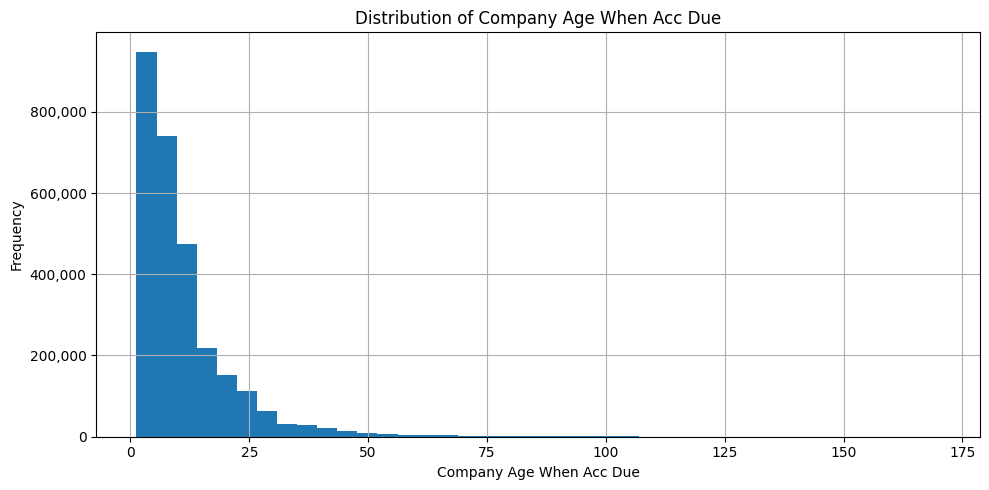

In [29]:
# Use the 'plot_histogram' helper function from 'visualisations.py'
plot_histogram(df, "company_age_when_acc_due", bins=40);

The histogram was produced to examine the distribution of company age when accounts become due. This confirms that the variable is highly right‑skewed, with most companies being relatively young and a long tail of older firms. While this is useful for understanding the shape of the data, the key modelling question is whether company age is associated with *late-filing*. The next step is therefore to analyse the *late‑filing rate* across different age bands to determine whether age has predictive value.

Logistic regression assumes a linear relationship between each numeric predictor and the log‑odds of the target. Strong right‑skew violates this assumption and can lead to unstable coefficients and reduced model performance. To assess whether the variable should be retained, transformed, or removed, I examine the relationship between *company_age_when_acc_due* and the late‑filing rate.

Due to the raw numeric age values being highly granular and not exhibiting a clear linear trend, the feature requires pre-processing before it can be used in the logistic regression model. Unlike PSC count, where capping the extreme tail was appropriate, company age is better handled by grouping the values into age bins. These bins can then be treated as categorical levels and *one‑hot encoded* in the modelling pipeline.

To address the strong right‑skew and the large concentration of younger companies, I used narrower bins at lower ages and wider at higher ages. This ensures that each bin contains a meaningful number of companies while still capturing the long tail of older firms.

The chosen bins reflect realistic company‑demographic groupings:
- **0–2** years    New companies
- **2–5** years    Young but more established
- **5–10** years   Mid‑range age
- **10–20** years  Mature companies
- **20+** years    Long‑standing companies

I then assign each company to an age bin and examine the proportion of companies in each bin.

In [30]:
# Place the values into meaningful categorical bins, allowing outliers to be dealt with in the upper level grouping.
df["company_age_when_acc_due"] = pd.cut(
    df["company_age_when_acc_due"],
    bins=[0, 2, 5, 10, 20, 200],
    labels=["0–2", "2–5", "5–10", "10–20", "20+"],
    include_lowest=True
)

# Check the distribution of the company_age_when_accounts_due using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "company_age_when_acc_due", hide_index=True, sort=True, sort_by="company_age_when_acc_due", ascending=True)

company_age_when_acc_due,count,percentage
0–2,"1,120",0.04%
2–5,"916,455",32.18%
5–10,"865,833",30.40%
10–20,"674,236",23.67%
20+,"390,612",13.71%


This table shows a good spread of ages across the bins.

## Final Modelling Data Composition

I will remove **"company_number"** as it is not a predictor variable, therefore is not needed for the logistic regression modelling. Then I will ensure that all columns are stored in the correct data types needed for the next stages of the model, before saving the final modelling dataset for the *CH_Log_Reg_Model.pynb*.

In [31]:
# Remove has_company_number as it is no longer needed, using the 'drop_columns_and_report' helper function from 'utils.py'
df = drop_columns_and_report(df, columns=["company_number"])

# Determine the type for each variable
dtype_map = {
    "company_category":         "category", # Character categorical variable of refactored company categories.
    "company_age_when_acc_due": "category", # Character categorical variable of binned ages.
    "accounts_group":           "category", # Character categorical variable of refactored accounts categories.
    "industry":                 "category", # Character categorical variable of refactored SIC codes.
    "registered_country":       "category", # Character categorical variable of refactored registered countries.
    "psc_count":                "category", # Character field indicating the number of pscs for a company, capped at 15+.
    "has_corporate_psc":        "int8",     # Binary 0/1 flag
    "has_foreign_psc":          "int8",     # Binary 0/1 flag
    "recent_psc_change":        "int8",     # Binary 0/1 flag
    "overdue":                  "int8",     # Binary 0/1 flag, feature engineered from filing dates
}

# Change the type of each variable
df = df.astype(dtype_map)

# Display the type of each column
df.dtypes.to_frame(name="data type")

rows: 2,848,256
columns: 10


,data type
company_category,category
company_age_when_acc_due,category
industry,category
registered_country,category
psc_count,category
has_corporate_psc,int8
has_foreign_psc,int8
recent_psc_change,int8
overdue,int8
accounts_group,category


In [32]:
# Ensure the columns are in the correct order.
ordered_cols = [
    "company_category",
    "accounts_group",
    "registered_country",
    "industry",
    "company_age_when_acc_due",
    "psc_count",
    "has_corporate_psc",
    "has_foreign_psc",
    "recent_psc_change",
    "overdue"   # target always last
]
df = df[ordered_cols].reset_index(drop=True)
# Display top 10 rows of the final dataset
df.head(10)

,company_category,accounts_group,registered_country,industry,company_age_when_acc_due,psc_count,has_corporate_psc,has_foreign_psc,recent_psc_change,overdue
0,LTD,SIMPLEST,ENGLAND,Admin & Support Services,5–10,1,0,1,0,0
1,LTD,REDUCED,ENGLAND,Information & Communication,5–10,3,0,1,0,0
2,LTD,SIMPLEST,UK,Accommodation & Food,5–10,2,0,1,0,1
3,LTD,SIMPLEST,ENGLAND,Admin & Support Services,5–10,1,0,1,0,0
4,LTD,MINIMAL,UNKNOWN,Wholesale & Retail,10–20,1,1,1,0,0
5,LTD,MINIMAL,ENGLAND,Wholesale & Retail,2–5,1,0,1,0,0
6,LTD,SIMPLEST,UK,Real Estate,2–5,2,0,0,0,0
7,LTD,SIMPLEST,ENGLAND,Information & Communication,10–20,2,0,1,0,0
8,LTD,SIMPLEST,UK,Real Estate,20+,2,0,1,0,0
9,LTD,SIMPLEST,ENGLAND,Wholesale & Retail,20+,2,0,1,0,0


In [33]:
# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "overdue", hide_index=True)

overdue,count,percentage
0,"2,590,974",90.97%
1,"257,282",9.03%


In [34]:
model_ready_data = df

# Save the final model ready dataset to the correct location
model_ready_data.to_parquet(model_ready_data_path, index=False)

# Ensure username is masked.
print(f"Final modelling dataset saved to:\n  {mask_user(str(model_ready_data_path))} on {date.today()}")

Final modelling dataset saved to:
  C:\Users\******\Documents\DS_Assignments\Companies_House\data_processed\model_ready_data.parquet on 2026-05-10


### Final Logistic Regression Model Dataset

A total of **9** predictor variables and **1** binary target variable were retained for the logistic regression modelling that will be conducted in 'CH_Log_Reg_Model.pynb'.

##### Columns Removed During EDA and Data Cleansing:
- **company_number:** A unique identifier with no behavioural meaning. It contains no variation relevant to behaviour and would distort the model if included.
- **country_of_origin:** All companies in the dataset shared the same country of origin, so the variable has no variation and no predictive value.
- **has_sanctioned_psc:** No companies had a sanctioned PSC. With zero variation, the feature could not contribute to prediction and was removed.


##### Feature/Predictor Variables Retained (with justification):
- **company_category:** These were mapped into fewer categories of legally meaningful groupings, (*LTD, LTD BY GUARANTEE/CIC, LLP and PLC*). Company legal form is a fundamental structural characteristic and a defensible predictor of administrative behaviour.
- **company_age_when_acc_due:** The raw ages were binned into meaningful real-world age bandings revealed clear differences in late-filing rates. Younger companies showed higher risk, while older firms were more compliant. The binned version captured this non-linear relationship and proved to be appropriate for logistic regression.
- **accounts_group:** This column was created from **accounts_category** which was mapped into fewer categories describing the style of accounts that companies are required to file, (*SIMPLEST, MINIMAL, REDUCED and FULL*).
- **industry:** Starting with **1008** categories in the variable, this was reduced down to **15** higher level *industries* categories instead, which is still a lot but its much more manageable for logisitic regression interpretability. Industry may affect behaviours in many ways, for example the seasonality of one category, or the oversight by solicitors and accountants etc. The industrial context is also operationally important and could directly inform which team within Companies House would conduct any investigative/supportive activity, and what type of activity that may be.
- **registered_country:** After imputing missing values to **UNKNOWN** and converting some anomalies into their true country category, the following categories remained *UK, ENGLAND, SCOTLAND, WALES, NORTHERN IRELAND and UNKNOWN*. Registered country could potentially be important and reflect different regulatory environments and more complex administrative patterns.
- **psc_count:** This variable was capped at **15** PSCs to remove outliers and the effect they would have on skewing the model. PSC count may be important as the absence of any PSC may indicate unusual organisational structure, which can be associated with administrative risk. The presence of a lot of PSCs may indicate layers of people that administration is required to pass through before submission, so may be more likely to be late where there are more PSCs.
- **has_corporate_psc:** This binary variable identifies whether a company’s controlling mind is a corporate entity rather than an individual. Corporate controlled firms may face different governance pressures or administrative practices, it is therefore retained.
- **has_foreign_psc:** This binary feature captures whether any PSC is registered outside the *UK*. This variable could provide useful contextual information in whether a company faces administrative legislations relevant outside of the *UK* and is retained.
- **recent_psc_change:** This binary variable indicates whether a company has undergone a recent change in its PSC structure. Companies with a recent PSC change may display very different filing behaviours, potentially reflecting organisational transitions, governance adjustments, or administrative disruption, therefore it is retained.
- **overdue:** This is the binary target variable, with **90.97%** not overdue and **9.03%** overdue. Although imbalanced, the minority class is still well‑represented in absolute terms (**257k** overdue cases). The imbalance reflects real‑world behaviour, where most companies comply and file *on-time*. This distribution represents the real‑world context of the problem and allows the model to learn realistic risk patterns.

## Next Steps
1. Reduces the dataset size by taking a sample of the data for speed of processing the logistic regression modelling.
2. Splits the sample data into "training" and "testing" datasets.
3. Explores each variable against the late-rate within the "training" dataset, refining which variables show predictive power and those that don't.
4. Check for multicollinearity within the remaining columns.
5. Builds the logistic regression model using the training dataset, conducting threshold tuning.
6. Tests the logisitc regression model using the testing dataset.
7. Analyses the coefficients to assess which variables have the most and least predictive power.
8. Explores the logistic regression against completely unseen data (df_discard from step 1).
9. Creates a population profile for the *high-risk* population identified by the logistic regression model.